<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_11_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from ucimlrepo import fetch_ucirepo

sns.set_theme()

# # (Mandatory)


### Q1. Feature & Target বিশ্লেষণ করো Kaggle এর Salary Prediction Dataset লোড করো। Years of Experience , Age, Education Level — এই তিনটি feature এবং Salary target এর মধ্যে relationship বোঝার জন্য:
- প্রতিটি feature এর বিপরীতে Salary এর scatter plot আঁকো
- correlation matrix বের করো
- কোন feature টি সবচেয়ে strongly linear সেটা লিখে জানাও


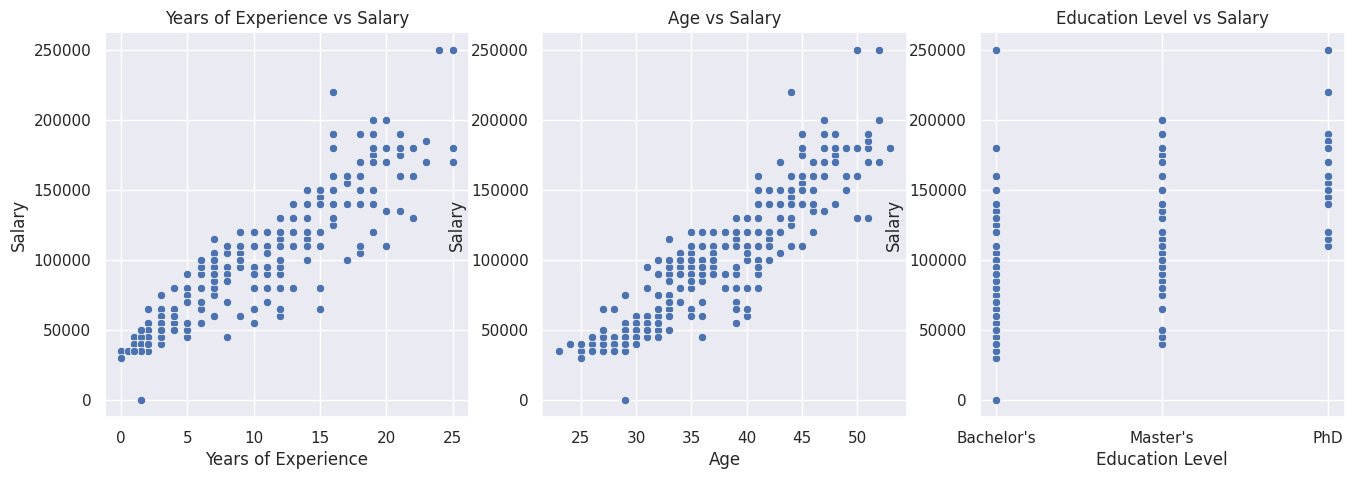

Correlation Matrix:
                      Years of Experience       Age    Salary
Years of Experience             1.000000  0.979128  0.930338
Age                             0.979128  1.000000  0.922335
Salary                          0.930338  0.922335  1.000000


In [ ]:
# load dataset
df_sal = pd.read_csv('Salary Data.csv')

# set feature and target
X = df_sal[['Years of Experience', 'Age', 'Education Level']]
y = df_sal['Salary']

# প্রতিটি feature এর বিপরীতে Salary এর scatter plot আঁকো
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cols in zip(axes, X):
  sns.scatterplot(data = df_sal, x = cols, y = y, ax = ax).set_title(f'{cols} vs Salary')

plt.show()

# correlation matrix বের করো
corr_matrix = df_sal[['Years of Experience', 'Age', 'Education Level', 'Salary']].corr(numeric_only=True)
print('Correlation Matrix:\n', corr_matrix)

# কোন feature টি সবচেয়ে strongly linear সেটা লিখে জানাও
# Ans: Years of Experience is strongly linear


# Q2. NumPy দিয়ে Prediction Function লেখো নিচের data manually define করো (অন্তত ১০টি row, ৩টি feature):
- Feature: study_hours, sleep_hours, attendance_pct → Target: exam_score
NumPy ব্যবহার করে:
- predict(X, w, b) function লেখো যেখানে y_pred = X @ w + b
- Random weights দিয়ে সব rows এর prediction করো এবং actual values এর সাথে পাশাপাশি print করো


In [ ]:
# Feature: study_hours, sleep_hours, attendance_pct → Target: exam_score NumPy ব্যবহার করে:
X = np.array([
    [6, 7, 85],
    [5, 6, 78],
    [8, 8, 92],
    [4, 5, 60],
    [7, 7, 88],
    [3, 6, 55],
    [9, 8, 95],
    [5, 7, 72],
    [6, 6, 80],
    [4, 4, 50]
])

y = np.array([72, 65, 88, 55, 82, 50, 95, 68, 75, 48])

np.random.seed(42)
w = np.random.randn(3)
b = np.random.randn()

# predict(X, w, b) function লেখো যেখানে y_pred = X @ w + b
def predict(X, w, b):
  return X @ w + b

# Random weights দিয়ে সব rows এর prediction করো এবং actual values এর সাথে পাশাপাশি print করো
y_pred = predict(X, w, b)

print(f"Weights : {w}")
print(f"Bias    : {b:.4f}")
print()
print(f"{'Row':<5} {'Predicted':>12} {'Actual':>10}")
print("-" * 30)

for i in range(len(y)):
    print(f"{i+1:<5} {y_pred[i]:>12.2f} {y[i]:>10}")

Weights : [ 0.49671415 -0.1382643   0.64768854]
Bias    : 1.5230

Row      Predicted     Actual
------------------------------
1            58.59         72
2            53.70         65
3            63.98         88
4            41.68         55
5            61.03         82
6            37.81         50
7            66.42         95
8            49.67         68
9            55.49         75
10           35.34         48


# Q3. Scikit-learn দিয়ে প্রথম Multiple Linear Regression (MLR) Model sklearn.datasets.fetch_california_housing() লোড করো।
- MedInc, AveRooms, HouseAge — শুধু এই ৩টি feature নাও
- LinearRegression দিয়ে model train করো
- coef_ এবং intercept_ print করো
- যেকোনো ৫টি sample এর predicted vs actual value দেখাও


In [ ]:
# load dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns = housing.feature_names)

# MedInc, AveRooms, HouseAge — শুধু এই ৩টি feature নাও
X = df_housing[['MedInc', 'AveRooms', 'HouseAge']]
y = housing.target

# LinearRegression দিয়ে model train করো
house_model = LinearRegression()
house_model.fit(X, y)

# coef_ এবং intercept_ print করো
weights = house_model.coef_
bias = house_model.intercept_
print('Weights:', weights)
print('Bias:', bias)

# যেকোনো ৫টি sample এর predicted vs actual value দেখাও
predicted_val = house_model.predict(X)
print('Predicted value:', predicted_val[:5])
print('Actual value:', y[:5])

Weights: [ 0.4427634  -0.02715343  0.01682208]
Bias: 0.020406956964582168
Predicted value: [4.20656308 3.87983989 3.88341489 3.23575221 2.42753784]
Actual value: [4.526 3.585 3.521 3.413 3.422]


# Q4. MSE Cost Function implement ও visualize করো Q2 এর data ব্যবহার করো।
- NumPy দিয়ে MSE cost function লেখো: J = (1/2m) * sum((y_pred - y)^2)
- w[0] কে -10 থেকে +10 এর মধ্যে vary করো, বাকি weights fixed রাখো
- Cost এর change একটি line plot এ দেখাও এবং minimum কোথায় সেটা mark করো


Minimum Cost: 2787.5811 at w[0] = 10.0000


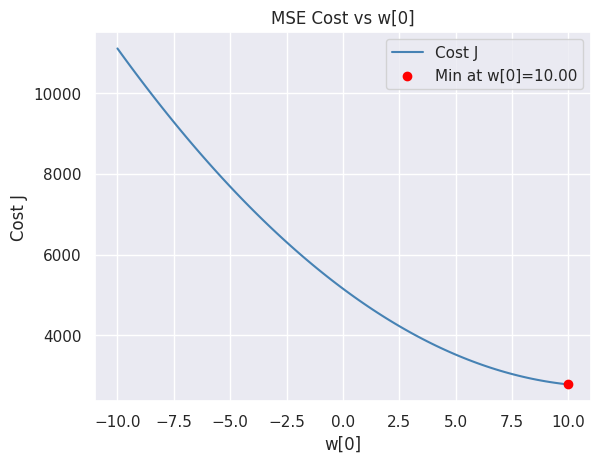

In [ ]:
X = np.array([
    [6, 7, 85], [5, 6, 78], [8, 8, 92], [4, 5, 60], [7, 7, 88],
    [3, 6, 55], [9, 8, 95], [5, 7, 72], [6, 6, 80], [4, 4, 50]
])
y = np.array([72, 65, 88, 55, 82, 50, 95, 68, 75, 48])

# NumPy দিয়ে MSE cost function লেখো: J = (1/2m) * sum((y_pred - y)^2)
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        cost += np.sum(error ** 2)

    cost = cost / (2 * m)   # ← moved outside the loop
    return cost

# w[0] কে -10 থেকে +10 এর মধ্যে vary করো, বাকি weights fixed রাখো
w0_values = np.linspace(-10, 10, 100)
costs = []

for w0 in w0_values:
  w_temp = w.copy()
  w_temp[0] = w0
  costs.append(compute_cost(X, y, w_temp, b))

# Cost এর change একটি line plot এ দেখাও এবং minimum কোথায় সেটা mark করো
min_idx = np.argmin(costs)
min_w0 = w0_values[min_idx]
min_cost = costs[min_idx]

print(f"Minimum Cost: {min_cost:.4f} at w[0] = {min_w0:.4f}")

plt.plot(w0_values, costs, color='steelblue', label='Cost J')
plt.scatter(min_w0, min_cost, color='red', zorder=5, label=f'Min at w[0]={min_w0:.2f}')
plt.title('MSE Cost vs w[0]')
plt.xlabel('w[0]')
plt.ylabel('Cost J')
plt.legend()
plt.grid(True)
plt.show()

# Q5. Gradient Descent from Scratch Advertising dataset (TV, Radio, Newspaper → Sales)।
- Gradient বের করার formula implement করো: dw = (1/m) * X.T @ (y_pred - y)
- Learning rate 0.01 দিয়ে ১০০০ iteration চালাও
- প্রতি ১০০ iteration এ cost print করো
- Cost vs Iteration curve plot করো এবং কোথায় converge করেছে সেটা দেখাও


Iteration 0: Cost 0.4923,dj_dw: [-0.8727833  -0.11118257 -0.06461714] ,dj_db : 2.1489754420400685e-16 w: [0.00872783 0.00111183 0.00064617], b: -0.0000
Iteration 100: Cost 0.2299,dj_dw: [-0.20585833 -0.17753659 -0.11116144] ,dj_db : 0.14090093689299238 w: [0.41627958 0.18161323 0.11830478], b: -0.1348
Iteration 200: Cost 0.1677,dj_dw: [-0.10095766 -0.12534512 -0.06277716] ,dj_db : 0.06496065891612808 w: [0.56048597 0.33132906 0.2035344 ], b: -0.2354
Iteration 300: Cost 0.1463,dj_dw: [-0.05337176 -0.09350076 -0.03389346] ,dj_db : 0.019235020017609218 w: [0.6348581  0.43907483 0.25030608], b: -0.2749
Iteration 400: Cost 0.1370,dj_dw: [-0.02806698 -0.07558946 -0.01801508] ,dj_db : -0.005073730758050088 w: [0.67414865 0.52268549 0.27539308], b: -0.2806
Iteration 500: Cost 0.1313,dj_dw: [-0.01446715 -0.06530626 -0.00925148] ,dj_db : -0.017680165365405974 w: [0.69464858 0.59262442 0.28855564], b: -0.2684
Iteration 600: Cost 0.1269,dj_dw: [-0.00716359 -0.05915307 -0.00434308] ,dj_db : -0.0239

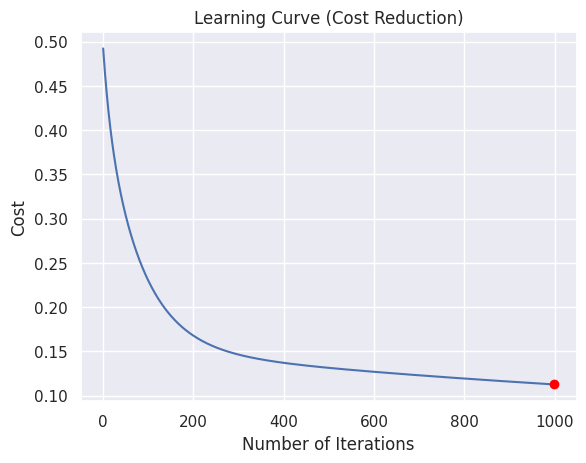

In [ ]:
# load dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv'
df_ad = pd.read_csv(url)

X = df_ad[['TV', 'radio', 'newspaper']].values
y = df_ad['sales'].values

# normalize
X = (X - X.mean()) / X.std()
y = (y - y.mean()) / y.std()

# Gradient বের করার formula implement করো: dw = (1/m) * X.T @ (y_pred - y)
m = X.shape[0]
n = X.shape[1]

def compute_cost(X, y, w, b):
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    prediction = np.dot(w, X[i]) + b
    error = prediction - y[i]
    cost += (error ** 2)

  cost = cost / (2 * m)
  return cost

def compute_gradient(X, y, w, b):
  m = X.shape[0]
  dj_dw = np.zeros(n)
  dj_db = 0

  for i in range(m):
    prediction = np.dot(w, X[i]) + b
    error = prediction - y[i]
    dj_db = dj_db + error

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * X[i, j])

  return dj_dw / m, dj_db / m

def gradient_descent(X, y, w_input, b_input, max_iter, alpha = 0.01):
    w = w_input
    b = b_input
    cost_memo = []
    iteration = []

    for i in range(max_iter):
      dj_dw, dj_db = compute_gradient(X, y, w, b)

      w = w - alpha * dj_dw
      b = b - alpha * dj_db

      cost = compute_cost(X, y, w, b)
      cost_memo.append(cost)
      iteration.append(i)

      # প্রতি ১০০ iteration এ cost print করো
      if i % 100 == 0:
        print(f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {w}, b: {b:0.4f}")

    return w, b, cost_memo, iteration

# Learning rate 0.01 দিয়ে ১০০০ iteration চালাও
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input = W_init, b_input = b_init, max_iter = 1000, alpha = 0.01)

# Cost vs Iteration curve plot করো এবং কোথায় converge করেছে সেটা দেখাও
plt.plot(iter_list, cost_memo)

# কোথায় converge করেছে
plt.scatter(iter_list[-1], cost_memo[-1], color='red', zorder=5, label=f'Converged at {cost_memo[-1]:.4f}')

plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()

# Q6. LinearRegression vs SGDRegressor তুলনা Energy Efficiency dataset (UCI) থেকে heating load predict করো।
- LinearRegression এবং SGDRegressor দুটোই একই data তে train করো
- দুটোর learned weights ও MSE পাশাপাশি একটি table এ দেখাও
- ২-৩ লাইনে লেখো কেন SGDRegressor এর weights exact match করে না

Covers: Scikit-learn SGDRegressor, why results differ


In [ ]:
# fetch dataset
energy_efficiency = fetch_ucirepo(id=242)

# data (as pandas dataframes)
X = energy_efficiency.data.features
y = energy_efficiency.data.targets['Y1']

# normalize (required for SGD to work properly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LinearRegression এবং SGDRegressor দুটোই একই data তে train করো
lin_model = LinearRegression()
lin_model.fit(X_scaled, y)
w_lin = lin_model.coef_
b_lin = lin_model.intercept_

sgd_model = SGDRegressor(penalty=None,max_iter=10000000,learning_rate="constant")
sgd_model.fit(X_scaled, y)
w_sgd = sgd_model.coef_
b_sgd = sgd_model.intercept_

# mse
y_pred_lin = lin_model.predict(X_scaled)
y_pred_sgd = sgd_model.predict(X_scaled)

mse_lin = mean_squared_error(y, y_pred_lin)
mse_sgd = mean_squared_error(y, y_pred_sgd)

feature_names = energy_efficiency.data.features.columns.tolist()

print(f"{'Feature':<25} {'LinearRegression':>18} {'SGDRegressor':>15}")
print("-" * 60)
for i, name in enumerate(feature_names):
    print(f"{name:<25} {w_lin[i]:>18.4f} {w_sgd[i]:>15.4f}")
print("-" * 60)
print(f"{'Bias':<25} {float(b_lin):>18.4f} {float(b_sgd):>15.4f}")
print(f"{'MSE':<25} {mse_lin:>18.4f} {mse_sgd:>15.4f}")

# ২-৩ লাইনে লেখো কেন SGDRegressor এর weights exact match করে না
# SGDRegressor weights won't match exactly across different runs or compared to traditional LinearRegression because the algorithm relies on randomness, dynamic learning steps, and iterative updates rather than a single exact mathematical formula. Due to random shuffling and fixed iterations, it never reaches the exact convergence point.

Feature                     LinearRegression    SGDRegressor
------------------------------------------------------------
X1                                   -6.8472         -4.9799
X2                                   -3.7670         -2.2909
X3                                    0.7113          0.9386
X4                                   -4.0169         -2.6873
X5                                    7.2974          7.9860
X6                                   -0.0261          0.0057
X7                                    2.6537          2.6672
X8                                    0.3158          0.3357
------------------------------------------------------------
Bias                                 22.3072         22.0938
MSE                                   8.5205          8.6749


/tmp/ipykernel_24320/2619565359.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"{'Bias':<25} {float(b_lin):>18.4f} {float(b_sgd):>15.4f}")


# (Optional)


# Q7. Learning Rate এর Effect পরীক্ষা করো Q5 এর Advertising dataset এবং তোমার নিজের Gradient Descent implementation ব্যবহার করো।
- চারটি আলাদা learning rate চালাও: 0.0001, 0.01, 0.1, 1.0
- সব ৪টির cost curve একই plot এ আঁকো (আলাদা color এ)
- কোন rate এ model diverge করে, কোনটিতে slow converge হয়, কোনটি optimal — সেটা সংখ্যা দিয়ে explain করো


Iteration 0: Cost 111.8358,dj_dw: [-4.07100612 -2.9988908  -1.18815867] ,dj_db : -14.022500000000003 w: [0.0004071  0.00029989 0.00011882], b: 0.0014
Iteration 100: Cost 109.6227,dj_dw: [-4.02820833 -2.96269774 -1.16354951] ,dj_db : -13.882966851799747 w: [0.04090065 0.03010563 0.01187579], b: 0.1409
Iteration 200: Cost 107.4542,dj_dw: [-3.98586979 -2.92697407 -1.13933593] ,dj_db : -13.744822150698559 w: [0.08096854 0.05955181 0.02338868], b: 0.2791
Iteration 300: Cost 105.3296,dj_dw: [-3.94398544 -2.89171348 -1.11551209] ,dj_db : -13.608052080729617 w: [0.12061535 0.0886431  0.03466141], b: 0.4158
Iteration 400: Cost 103.2478,dj_dw: [-3.90255029 -2.85690974 -1.09207224] ,dj_db : -13.472642963404088 w: [0.15984558 0.1173841  0.04569784], b: 0.5512
Iteration 500: Cost 101.2080,dj_dw: [-3.86155941 -2.82255674 -1.06901071] ,dj_db : -13.33858125634317 w: [0.19866371 0.14577934 0.05650179], b: 0.6853
Iteration 600: Cost 99.2093,dj_dw: [-3.82100793 -2.78864841 -1.04632191] ,dj_db : -13.20585

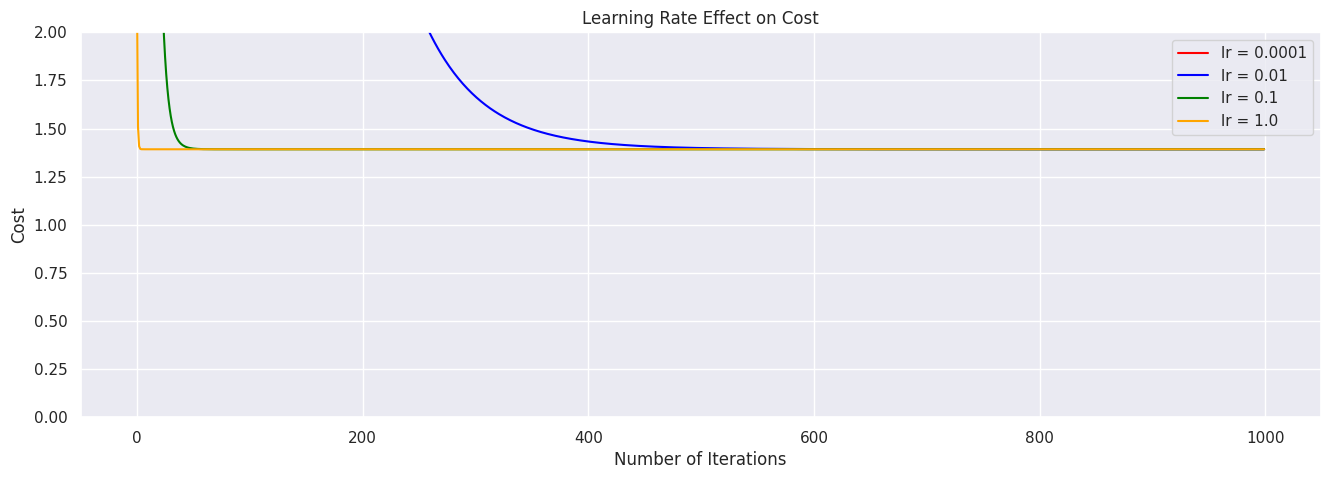

In [ ]:
X = df_ad[['TV', 'radio', 'newspaper']].values
y = df_ad['sales'].values

X = (X - X.mean(axis=0)) / X.std(axis=0)

m = X.shape[0]
n = X.shape[1]

# চারটি আলাদা learning rate চালাও: 0.0001, 0.01, 0.1, 1.0
alphas = [0.0001, 0.01, 0.1, 1.0]
colors = ['red', 'blue', 'green', 'orange']

plt.figure(figsize=(16, 5))

for alpha, color in zip(alphas, colors):
  W_init = np.zeros((n,))
  b_init = 0.0

  w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input = W_init, b_input = b_init, max_iter = 1000, alpha = alpha)

  # কোন rate এ model diverge করে, কোনটিতে slow converge হয়, কোনটি optimal — সেটা সংখ্যা দিয়ে explain করো
  print(f"alpha={alpha}: Final Cost = {cost_memo[-1]:.4f}")

  # সব ৪টির cost curve একই plot এ আঁকো (আলাদা color এ)
  plt.plot(iter_list, cost_memo, color = color, label = f'lr = {alpha}')

plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Rate Effect on Cost")
plt.ylim(0, 2)        # clip y-axis so diverged curve doesn't squish others
plt.legend()
plt.grid(True)
plt.show()

# Q8. কেন Visualization কঠিন — practically দেখাও California Housing dataset এর যেকোনো ২টি feature নাও।
- matplotlib এর plot_surface দিয়ে ২ feature → target এর 3D regression plane visualize করো
- এরপর ৩টি feature দিয়ে model train করো এবং same ভাবে visualize করার চেষ্টা করো
- কোড সহ explain করো ঠিক কোন জায়গায় visualization আর possible না এবং কেন


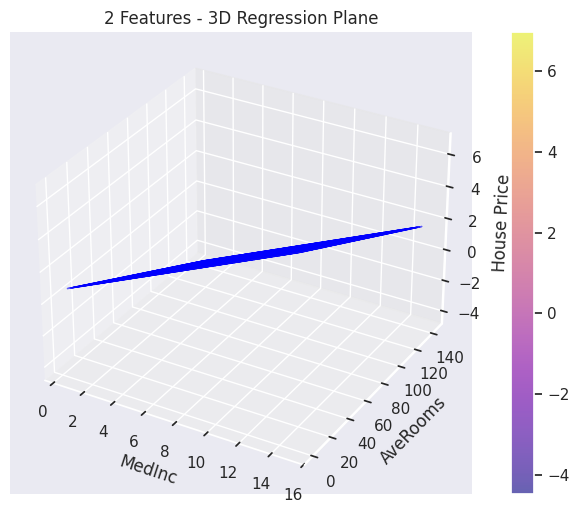

Visualization failed: Argument Z must be 2-dimensional.
3 features → 4D space needed → not possible with plot_surface


In [ ]:
# California Housing dataset এর যেকোনো ২টি feature নাও।
X2 = df_housing[['MedInc', 'AveRooms']].values
y = housing.target

# এরপর ৩টি feature দিয়ে model train করো এবং same ভাবে visualize করার চেষ্টা করো
model = LinearRegression()
model.fit(X2, y)

# matplotlib এর plot_surface দিয়ে ২ feature → target এর 3D regression plane visualize করো
f1_range = np.linspace(X2[:, 0].min(), X2[:, 0].max(), 50)
f2_range = np.linspace(X2[:, 1].min(), X2[:, 1].max(), 50)
f1_grid, f2_grid = np.meshgrid(f1_range, f2_range)

X_grid = np.c_[f1_grid.ravel(), f2_grid.ravel()]
y_grid = model.predict(X_grid).reshape(f1_grid.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(f1_grid, f2_grid, y_grid, alpha=0.6, cmap='plasma', edgecolor='blue')
ax.set_xlabel('MedInc')
ax.set_ylabel('AveRooms')
ax.set_zlabel('House Price')
ax.set_title('2 Features - 3D Regression Plane')
fig.colorbar(surf)
plt.show()

# ৩টি feature দিয়ে model train করো
X3 = df_housing[['MedInc', 'AveRooms', 'HouseAge']].values

model3 = LinearRegression()
model3.fit(X3, y)

# same ভাবে visualize করার চেষ্টা
f1_range = np.linspace(X3[:, 0].min(), X3[:, 0].max(), 50)
f2_range = np.linspace(X3[:, 1].min(), X3[:, 1].max(), 50)
f3_range = np.linspace(X3[:, 2].min(), X3[:, 2].max(), 50)

f1_grid, f2_grid, f3_grid = np.meshgrid(f1_range, f2_range, f3_range)

# ❌ এখানেই visualization impossible হয়ে যায়
# f1_grid, f2_grid, f3_grid — এই ৩টা axis ই শেষ
# কিন্তু target (House Price) রাখার জন্য 4th axis দরকার
# matplotlib এর plot_surface শুধু 3 axis সাপোর্ট করে: (X, Y, Z)
# Z তে target রাখতে হলে X, Y তে শুধু ২টা feature রাখা যাবে
# ৩য় feature আসলেই Z আর target এর জন্য আলাদা axis নেই

X_grid = np.c_[f1_grid.ravel(), f2_grid.ravel(), f3_grid.ravel()]
y_grid = model3.predict(X_grid)  # shape: (125000,) — কিন্তু কোথায় plot করবো?

# y_grid কে reshape করতে হলে 4D array লাগবে: (50, 50, 50, 1)
# plot_surface নেয় শুধু 2D grid → impossible
try:
    y_grid = y_grid.reshape(f1_grid.shape)   # (50, 50, 50) — 3D, not 2D
    ax.plot_surface(f1_grid, f2_grid, y_grid) # ❌ crashes: needs 2D arrays
except Exception as e:
    print(f"Visualization failed: {e}")
    print("3 features → 4D space needed → not possible with plot_surface")

# Q9. Real-world End-to-End Project Melbourne Housing dataset (Kaggle) নাও।
- Relevant numeric features বেছে নাও, missing values handle করো
- Feature ও target এর relationship analyze করো (scatter + correlation)
- NumPy দিয়ে Gradient Descent চালিয়ে model train করো
- Sklearn দিয়েও train করো
- দুটোর MSE compare করো এবং কোনো feature এর coefficient negative হলে real-world এ সেটার meaning explain করো


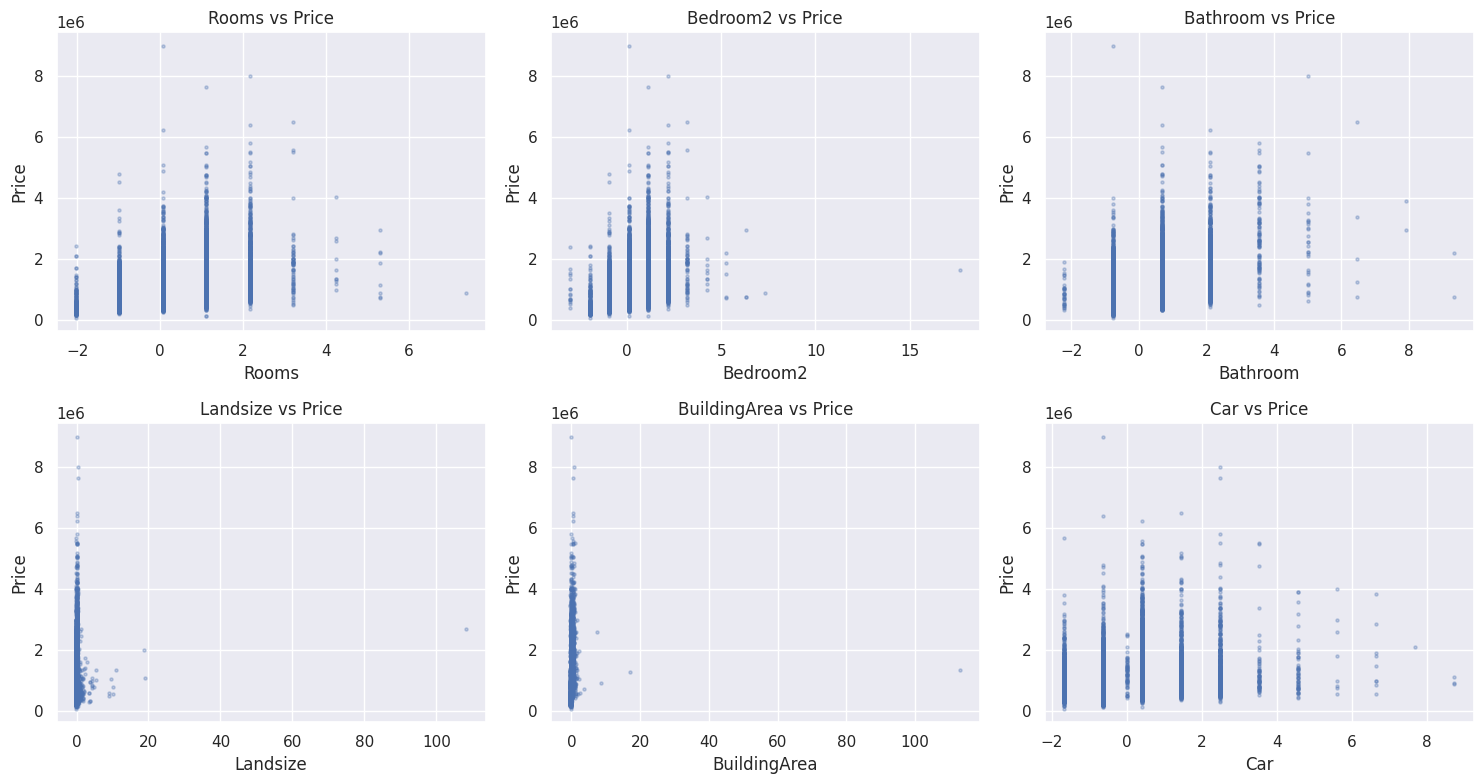

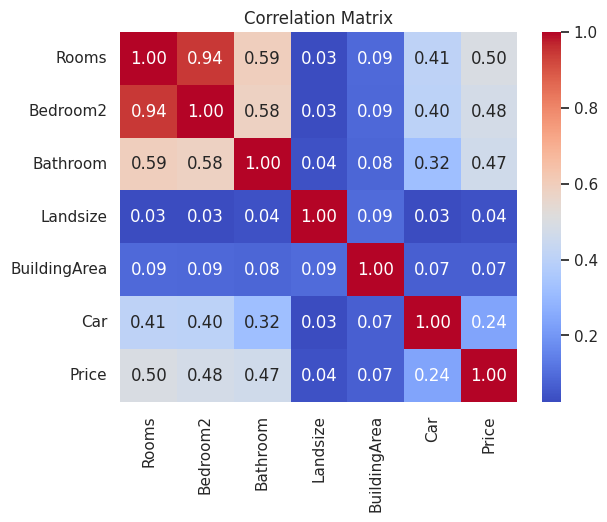

Iteration:0, Cost:768336822204.7648, b:10756.8408
Iteration:100, Cost:221976817315.6236, b:685886.2690
Iteration:200, Cost:155307229473.5833, b:933005.4743
Iteration:300, Cost:146269693947.3275, b:1023459.0956
Iteration:400, Cost:144991471097.1594, b:1056568.0463
Iteration:500, Cost:144775849149.6214, b:1068686.9931
Iteration:600, Cost:144712406968.0098, b:1073122.9196
Iteration:700, Cost:144674700943.8750, b:1074746.6121
Iteration:800, Cost:144644102768.7479, b:1075340.9361
Iteration:900, Cost:144617352325.6614, b:1075558.4779
NumPy GD MSE        : 289187603998.77
LinearRegression MSE: 288785399909.10
SGDRegressor MSE    : 13684850638355437568.00
Rooms: 211720.70 → price increases
Bedroom2: 620.22 → price increases
Bathroom: 167954.38 → price increases
Landsize: 11135.35 → price increases
BuildingArea: 9082.78 → price increases
Car: 10993.21 → price increases


In [ ]:
# load dataset
df_melb = pd.read_csv('melb_data.csv')

features = ['Rooms', 'Bedroom2', 'Bathroom', 'Landsize', 'BuildingArea', 'Car']

df_melb[features] = df_melb[features].fillna(df_melb[features].mean())
df_melb['Price'] = df_melb['Price'].fillna(df_melb['Price'].mean())

X = df_melb[features].values
y = df_melb['Price'].values

# normalize once, use everywhere
scaler = StandardScaler()
X = scaler.fit_transform(X)

m = X.shape[0]
n = X.shape[1]

# scatter
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, feature in enumerate(features):
    axes[i].scatter(X[:, i], y, alpha=0.3, s=5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'{feature} vs Price')
plt.tight_layout()
plt.show()

# correlation
corr = df_melb[features + ['Price']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# numpy gradient descent
def compute_cost(X, y, w, b):
    m = X.shape[0]
    y_pred = X @ w + b
    return (1 / (2 * m)) * np.sum((y_pred - y) ** 2)

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    y_pred = X @ w + b
    error = y_pred - y
    dj_dw = (1 / m) * X.T @ error
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db

def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
    w = w_input
    b = b_input
    cost_memo = []
    iteration = []
    for i in range(max_iter):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost = compute_cost(X, y, w, b)
        cost_memo.append(cost)
        iteration.append(i)
        if i % 100 == 0:
            print(f'Iteration:{i}, Cost:{cost:.4f}, b:{b:.4f}')
    return w, b, cost_memo, iteration

W_init = np.zeros((n,))
b_init = 0.0
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=W_init, b_input=b_init, max_iter=1000, alpha=0.01)

# sklearn
lin = LinearRegression()
lin.fit(X, y)
w_lin = lin.coef_
b_lin = lin.intercept_

sgd = SGDRegressor(penalty=None, max_iter=10000000, learning_rate="constant")
sgd.fit(X, y)
w_sgd = sgd.coef_
b_sgd = sgd.intercept_

# mse compare — all use same X
y_pred_numpy = X @ w_final + b_final
y_pred_lin   = lin.predict(X)
y_pred_sgd   = sgd.predict(X)

mse_numpy = mean_squared_error(y, y_pred_numpy)
mse_lin   = mean_squared_error(y, y_pred_lin)
mse_sgd   = mean_squared_error(y, y_pred_sgd)

print(f"NumPy GD MSE        : {mse_numpy:.2f}")
print(f"LinearRegression MSE: {mse_lin:.2f}")
print(f"SGDRegressor MSE    : {mse_sgd:.2f}")

# coefficient analysis
for name, coef in zip(features, w_lin):
    print(f"{name}: {coef:.2f} → {'price increases' if coef > 0 else 'price decreases'}")